<a href="https://colab.research.google.com/github/parthnijh/intro-to-pytorch/blob/main/GPU_Pytorch_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import torch
import torch.nn as nn
torch.manual_seed(42)

In [17]:
device=torch.device("cuda" if torch.cuda.is_available() else 'cpu')
print(f"{device}")

cuda


In [3]:
df=pd.read_csv("/content/drive/MyDrive/fashion-mnist_train.csv")
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


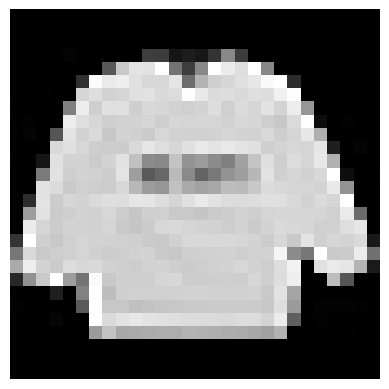

In [4]:
import matplotlib.pyplot as plt

label = df.iloc[0, 0]        # first column
image = df.iloc[0, 1:].values  # remaining 784 pixels
image=image.reshape(28,28)


plt.imshow(image, cmap="gray")

plt.axis("off")
plt.show()

In [7]:
X=df.iloc[:,1:].values
y=df.iloc[:,0].values


In [8]:

from sklearn.model_selection import train_test_split
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2)

In [9]:
Xtrain= Xtrain/255.0

Xtest=Xtest/255.0

In [10]:
from torch.utils.data import Dataset,DataLoader
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features=torch.tensor(features,dtype=torch.float32)
    self.labels=torch.tensor(labels,dtype=torch.long)



  def __len__(self):
    return len(self.features)


  def __getitem__(self,idx):
    return self.features[idx],self.labels[idx]



In [11]:
train_dataset=CustomDataset(Xtrain,ytrain)
len(train_dataset)

48000

In [12]:
test_dataset=CustomDataset(Xtest,ytest)


In [13]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False)

In [14]:

class MyNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.model=nn.Sequential(
        nn.Linear(num_features,128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(128,64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(64,10)


    )


  def forward(self,x):
    return self.model(x)





In [15]:
epochs=100
learning_rate=0.1


In [22]:
model=MyNN(Xtrain.shape[1])
model=model.to(device)
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate,weight_decay=1e-4)


In [ ]:
for data in train_loader:
  print(data)

[tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0588, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]), tensor([3, 2, 9, 8, 5, 1, 5, 3, 6, 3, 2, 7, 5, 1, 7, 2, 9, 5, 2, 6, 8, 1, 3, 4,
        5, 5, 8, 9, 4, 3, 8, 5])]
[tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0039,  ..., 0.0000, 0.0000, 0.0000]]), tensor([2, 9, 7, 1, 2, 0, 9, 6, 1, 2, 0, 9, 7, 8, 8, 7, 4, 8, 8, 1, 4, 3, 4, 2,
      

In [19]:
#training loop
for epoch in range(epochs):
  totalloss=0
  for batch_features,batch_labels in train_loader:
    batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
    #forward pass
    out=model(batch_features)
    #calculate loss
    loss=criterion(out,batch_labels)
    #back pass
    optimizer.zero_grad()
    loss.backward()
    #update grads
    optimizer.step()

    totalloss=totalloss+loss.item()
  avgloss=totalloss/len(train_loader)
  print(f"Epoch{epoch+1} Loss{avgloss}")

Epoch1 Loss0.6410403288900852
Epoch2 Loss0.4315733361442884
Epoch3 Loss0.3817212237268686
Epoch4 Loss0.35321725078175464
Epoch5 Loss0.33608218881487845
Epoch6 Loss0.3165918896496296
Epoch7 Loss0.30492583751430113
Epoch8 Loss0.2916068989038467
Epoch9 Loss0.28180039874464274
Epoch10 Loss0.27206993999828893
Epoch11 Loss0.26352764110763865
Epoch12 Loss0.255848905702432
Epoch13 Loss0.2475887572467327
Epoch14 Loss0.24286397133767604
Epoch15 Loss0.23425325182576975
Epoch16 Loss0.23263242275143664
Epoch17 Loss0.22547830425327023
Epoch18 Loss0.2176409853932758
Epoch19 Loss0.21200391347830494
Epoch20 Loss0.2095471213236451
Epoch21 Loss0.20582340492742757
Epoch22 Loss0.19873812212670844
Epoch23 Loss0.1957515357931455
Epoch24 Loss0.19179632556190093
Epoch25 Loss0.18843679743632674
Epoch26 Loss0.18409127650037407
Epoch27 Loss0.17818024443338315
Epoch28 Loss0.17355218395590782
Epoch29 Loss0.17386495602627594
Epoch30 Loss0.16954134575556964
Epoch31 Loss0.16594342755153776
Epoch32 Loss0.16263812268587

In [20]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [21]:
correct = 0
total = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
        out = model(batch_features)              # shape: (batch_size, 10)

        pred = torch.argmax(out, dim=1)         # pick highest score per row

        correct += (pred == batch_labels).sum().item()
        total += batch_labels.size(0)

accuracy = correct / total
print("Accuracy:", accuracy)

Accuracy: 0.88225
